In [1]:
# 1. Imports & Configuration
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix
from mlxtend.frequent_patterns import apriori, association_rules
warnings.filterwarnings("ignore")

# =====================================================================
#  GLOBAL DEEP SPACE / GALAXY THEME
# =====================================================================
# Cosmic Backgrounds and Neutrals
GALAXY_BG = '#030014'          # Extremely deep space void
GALAXY_FG = '#E2E8F0'          # Starlight white/silver
GALAXY_GRID = 'rgba(255, 255, 255, 0.05)' # Faint stardust grid lines

# Vibrant Nebula Accents (Cyber-cosmic)
GALAXY_ACCENT1 = '#FF007F'     # Nebula Pink
GALAXY_ACCENT2 = '#00F0FF'     # Cosmic Cyan
GALAXY_ACCENT3 = '#AA00FF'     # Deep Pulsar Purple
GALAXY_ACCENT4 = '#FFEA00'     # Solar Yellow
GALAXY_ACCENT5 = '#39FF14'     # Alien Plasma Green
GALAXY_ACCENT6 = '#1A73E8'     # Deep Galaxy Blue

# Standard Categorical Palette (NASA Kepler states)
GALAXY_CLASS_PALETTE = {
    'CONFIRMED': GALAXY_ACCENT2,    # Cyan
    'FALSE POSITIVE': GALAXY_ACCENT1, # Pink
    'CANDIDATE': GALAXY_ACCENT3     # Purple
}
GALAXY_PALETTE = [GALAXY_ACCENT2, GALAXY_ACCENT1, GALAXY_ACCENT3, GALAXY_ACCENT4, GALAXY_ACCENT5, GALAXY_ACCENT6]

# Continuous Colormaps
from matplotlib.colors import LinearSegmentedColormap
GALAXY_CMAP = LinearSegmentedColormap.from_list('galaxy_sequential', [GALAXY_BG, GALAXY_ACCENT3, GALAXY_ACCENT2, GALAXY_FG])
GALAXY_DIVERGING_CMAP = LinearSegmentedColormap.from_list('galaxy_diverge', [GALAXY_ACCENT1, GALAXY_BG, GALAXY_ACCENT2])

# Model Color Mapping for Consistency
GALAXY_MODEL_COLORS = [GALAXY_ACCENT1, GALAXY_ACCENT2, GALAXY_ACCENT5, GALAXY_ACCENT4, GALAXY_ACCENT3]

# =====================================================================
#  THEME APPLICATION FUNCTIONS
# =====================================================================
def apply_galaxy_figure(fig, facecolor=GALAXY_BG):
    """Applies deep space background to a Matplotlib Figure."""
    fig.patch.set_facecolor(facecolor)
    fig.patch.set_edgecolor(facecolor)

def apply_galaxy_axes(ax, grid=True, title_color=GALAXY_FG, facecolor=GALAXY_BG):
    """Applies galaxy theme to Matplotlib Axes cleanly."""
    ax.set_facecolor(facecolor)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color(GALAXY_FG)
    ax.spines['left'].set_color(GALAXY_FG)
    
    ax.tick_params(axis='x', colors=GALAXY_FG, labelsize=10)
    ax.tick_params(axis='y', colors=GALAXY_FG, labelsize=10)
    
    ax.xaxis.label.set_color(GALAXY_FG)
    ax.yaxis.label.set_color(GALAXY_FG)
    ax.xaxis.label.set_weight('bold')
    ax.yaxis.label.set_weight('bold')
    
    if ax.title.get_text():
        ax.title.set_color(title_color)
        ax.title.set_weight('bold')
        ax.title.set_size(13)

    if grid:
        # Use an extremely faint white string for the grid
        ax.grid(True, linestyle=':', linewidth=0.5, color='#ffffff', alpha=0.1, zorder=0)

def style_galaxy_legend(legend):
    """Applies deep space theme to a Matplotlib legend."""
    if legend:
        legend.get_frame().set_facecolor((0.01, 0.0, 0.08, 0.7)) # RGBA tuple instead of string
        legend.get_frame().set_edgecolor(GALAXY_FG)
        for text in legend.get_texts():
            text.set_color(GALAXY_FG)

def apply_galaxy_plotly(fig):
    """Applies galaxy theme to Plotly figures."""
    fig.update_layout(
        plot_bgcolor=GALAXY_BG,
        paper_bgcolor=GALAXY_BG,
        font=dict(color=GALAXY_FG),
        title_font=dict(color=GALAXY_FG, size=20, family="Arial, bold"),
        legend=dict(
            bgcolor='rgba(3, 0, 20, 0.7)', 
            bordercolor=GALAXY_FG,
            borderwidth=1,
            font=dict(color=GALAXY_FG)
        ),
        margin=dict(l=40, r=40, t=60, b=40)
    )
    
    axis_styling = dict(
        showgrid=True, gridcolor='rgba(255, 255, 255, 0.05)', gridwidth=1,
        zeroline=True, zerolinecolor=GALAXY_FG, zerolinewidth=1,
        showline=True, linecolor=GALAXY_FG, linewidth=1,
        tickfont=dict(color=GALAXY_FG)
    )
    
    if 'xaxis' in fig.layout: fig.update_xaxes(**axis_styling)
    if 'yaxis' in fig.layout: fig.update_yaxes(**axis_styling)
    if 'scene' in fig.layout:
        fig.update_layout(scene=dict(
            xaxis=dict(showgrid=True, gridcolor='rgba(255, 255, 255, 0.1)', zerolinecolor=GALAXY_FG, backgroundcolor=GALAXY_BG, color=GALAXY_FG),
            yaxis=dict(showgrid=True, gridcolor='rgba(255, 255, 255, 0.1)', zerolinecolor=GALAXY_FG, backgroundcolor=GALAXY_BG, color=GALAXY_FG),
            zaxis=dict(showgrid=True, gridcolor='rgba(255, 255, 255, 0.1)', zerolinecolor=GALAXY_FG, backgroundcolor=GALAXY_BG, color=GALAXY_FG)
        ))

# Set Seaborn global context
sns.set_theme(style='darkgrid', rc={
    'axes.facecolor': GALAXY_BG,
    'figure.facecolor': GALAXY_BG,
    'axes.edgecolor': GALAXY_FG,
    'grid.color': '#ffffff',
    'grid.linestyle': ':',
    'grid.alpha': 0.1,
    'text.color': GALAXY_FG,
    'xtick.color': GALAXY_FG,
    'ytick.color': GALAXY_FG,
    'axes.labelcolor': GALAXY_FG,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

def galaxy_table_styles():
    """Returns CSS styles for pandas Styler objects."""
    return [
        {'selector': 'th', 'props': [('background-color', '#120d2b'), ('color', GALAXY_ACCENT2), ('font-weight', 'bold'), ('border', '1px solid #201a40')]},
        {'selector': 'td', 'props': [('border', '1px solid #201a40')]},
        {'selector': 'table', 'props': [('background-color', GALAXY_BG), ('color', GALAXY_FG), ('border-collapse', 'collapse')]},
        {'selector': 'tr:hover td', 'props': [('background-color', '#1a0b3b')]} # Pink/Purple glow effect on hover
    ]

## 2. Data Loading & Basic EDA

In [2]:
df = pd.read_csv("../data/cumulative.csv")
display(df.head())
display(df.info())
display(df.describe())
display(df['koi_disposition'].value_counts())

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


<class 'pandas.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              9564 non-null   int64  
 1   kepid              9564 non-null   int64  
 2   kepoi_name         9564 non-null   str    
 3   kepler_name        2294 non-null   str    
 4   koi_disposition    9564 non-null   str    
 5   koi_pdisposition   9564 non-null   str    
 6   koi_score          8054 non-null   float64
 7   koi_fpflag_nt      9564 non-null   int64  
 8   koi_fpflag_ss      9564 non-null   int64  
 9   koi_fpflag_co      9564 non-null   int64  
 10  koi_fpflag_ec      9564 non-null   int64  
 11  koi_period         9564 non-null   float64
 12  koi_period_err1    9110 non-null   float64
 13  koi_period_err2    9110 non-null   float64
 14  koi_time0bk        9564 non-null   float64
 15  koi_time0bk_err1   9110 non-null   float64
 16  koi_time0bk_err2   9110 non-null   

None

,rowid,kepid,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
count,9564.000000,9.564000e+03,8054.000000,9564.000000,9564.000000,9564.000000,9564.000000,9564.000000,9110.000000,9110.000000,...,9081.000000,9201.000000,9096.000000,9096.000000,9201.000000,9096.000000,9096.000000,9564.000000,9564.000000,9563.000000
mean,4782.500000,7.690628e+06,0.480829,0.188206,0.231598,0.194898,0.120033,75.671358,0.002148,-0.002148,...,-162.265059,4.310157,0.120738,-0.143161,1.728712,0.362292,-0.394806,292.060163,43.810433,14.264606
std,2761.033321,2.653459e+06,0.476928,0.390897,0.421875,0.396143,0.325018,1334.744046,0.008236,0.008236,...,72.746348,0.432606,0.132837,0.085477,6.127185,0.930870,2.168213,4.766657,3.601243,1.385448
min,1.000000,7.574500e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.241843,0.000000,-0.172500,...,-1762.000000,0.047000,0.000000,-1.207000,0.109000,0.000000,-116.137000,279.852720,36.577381,6.966000
25%,2391.750000,5.556034e+06,0.000000,0.000000,0.000000,0.000000,0.000000,2.733684,0.000005,-0.000276,...,-198.000000,4.218000,0.042000,-0.196000,0.829000,0.129000,-0.250000,288.660770,40.777173,13.440000
50%,4782.500000,7.906892e+06,0.334000,0.000000,0.000000,0.000000,0.000000,9.752831,0.000035,-0.000035,...,-160.000000,4.438000,0.070000,-0.128000,1.000000,0.251000,-0.111000,292.261125,43.677504,14.520000
75%,7173.250000,9.873066e+06,0.998000,0.000000,0.000000,0.000000,0.000000,40.715178,0.000276,-0.000005,...,-114.000000,4.543000,0.149000,-0.088000,1.345000,0.364000,-0.069000,295.859160,46.714611,15.322000
max,9564.000000,1.293514e+07,1.000000,1.000000,1.000000,1.000000,1.000000,129995.778400,0.172500,0.000000,...,0.000000,5.364000,1.472000,0.000000,229.908000,33.091000,0.000000,301.720760,52.336010,20.003000


koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64

## 3. Data Cleaning & Feature Selection

In [3]:
# 1. Define columns to drop (ID and non-predictive metadata)
cols_to_drop = [
    'rowid', 'kepid', 'kepoi_name', 'kepler_name', 
    'koi_pdisposition', 'koi_score',                
    'koi_tce_delivname', 'koi_tce_plnt_num'         
]
# 2. Collect all error/uncertainty columns (containing 'err')
err_columns = [col for col in df.columns if 'err' in col]
# 3. Combine drop lists
final_drop_list = cols_to_drop + err_columns
# 4. Perform the drop to clean the dataframe
df_cleaned = df.drop(columns=final_drop_list)
# 5. Define the physical feature columns (include False Positive flags)
physical_features = [
    'koi_period', 'koi_time0bk', 'koi_impact', 'koi_duration',
    'koi_depth', 'koi_prad', 'koi_teq', 'koi_insol',
    'koi_model_snr', 'koi_steff', 'koi_slogg', 'koi_srad',
    'ra', 'dec', 'koi_kepmag',
    'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec'
]

# 6. Final selection
df_final = df_cleaned[physical_features + ['koi_disposition']].copy()

# Display summary for confirmation
print(f"Final Data Shape: {df_final.shape}")
df_final.head()

Final Data Shape: (9564, 20)


,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_disposition
0,9.488036,170.538750,0.146,2.95750,615.8,2.26,793.0,93.59,35.8,5455.0,4.467,0.927,291.93423,48.141651,15.347,0,0,0,0,CONFIRMED
1,54.418383,162.513840,0.586,4.50700,874.8,2.83,443.0,9.11,25.8,5455.0,4.467,0.927,291.93423,48.141651,15.347,0,0,0,0,CONFIRMED
2,19.899140,175.850252,0.969,1.78220,10829.0,14.60,638.0,39.30,76.3,5853.0,4.544,0.868,297.00482,48.134129,15.436,0,1,0,0,FALSE POSITIVE
3,1.736952,170.307565,1.276,2.40641,8079.2,33.46,1395.0,891.96,505.6,5805.0,4.564,0.791,285.53461,48.285210,15.597,0,1,0,0,FALSE POSITIVE
4,2.525592,171.595550,0.701,1.65450,603.3,2.75,1406.0,926.16,40.9,6031.0,4.438,1.046,288.75488,48.226200,15.509,0,0,0,0,CONFIRMED


In [4]:
# Check missing values
df_final.isnull().sum()

koi_period           0
koi_time0bk          0
koi_impact         363
koi_duration         0
koi_depth          363
koi_prad           363
koi_teq            363
koi_insol          321
koi_model_snr      363
koi_steff          363
koi_slogg          363
koi_srad           363
ra                   0
dec                  0
koi_kepmag           1
koi_fpflag_nt        0
koi_fpflag_ss        0
koi_fpflag_co        0
koi_fpflag_ec        0
koi_disposition      0
dtype: int64

In [5]:
for col in df_final.columns:
    if df_final[col].dtype != 'object':
        if df_final[col].isnull().any():
            median_val = df_final[col].median()
            df_final[col] = df_final[col].fillna(median_val)

## 4. Exploratory Data Analysis (EDA)

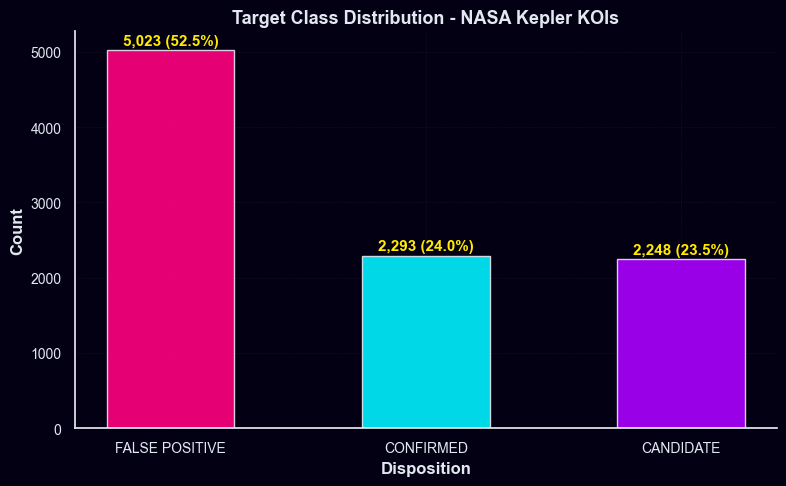

In [6]:
# Target Distribution
counts = df_final['koi_disposition'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
colors = [GALAXY_CLASS_PALETTE.get(label, GALAXY_ACCENT1) for label in counts.index]
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor=GALAXY_FG, width=0.5, alpha=0.9)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 30,
            f'{val:,} ({val/len(df_final)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color=GALAXY_ACCENT4)

ax.set_title('Target Class Distribution - NASA Kepler KOIs', fontsize=14, fontweight='bold')
ax.set_xlabel('Disposition', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
apply_galaxy_axes(ax)
plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=150)
plt.show()


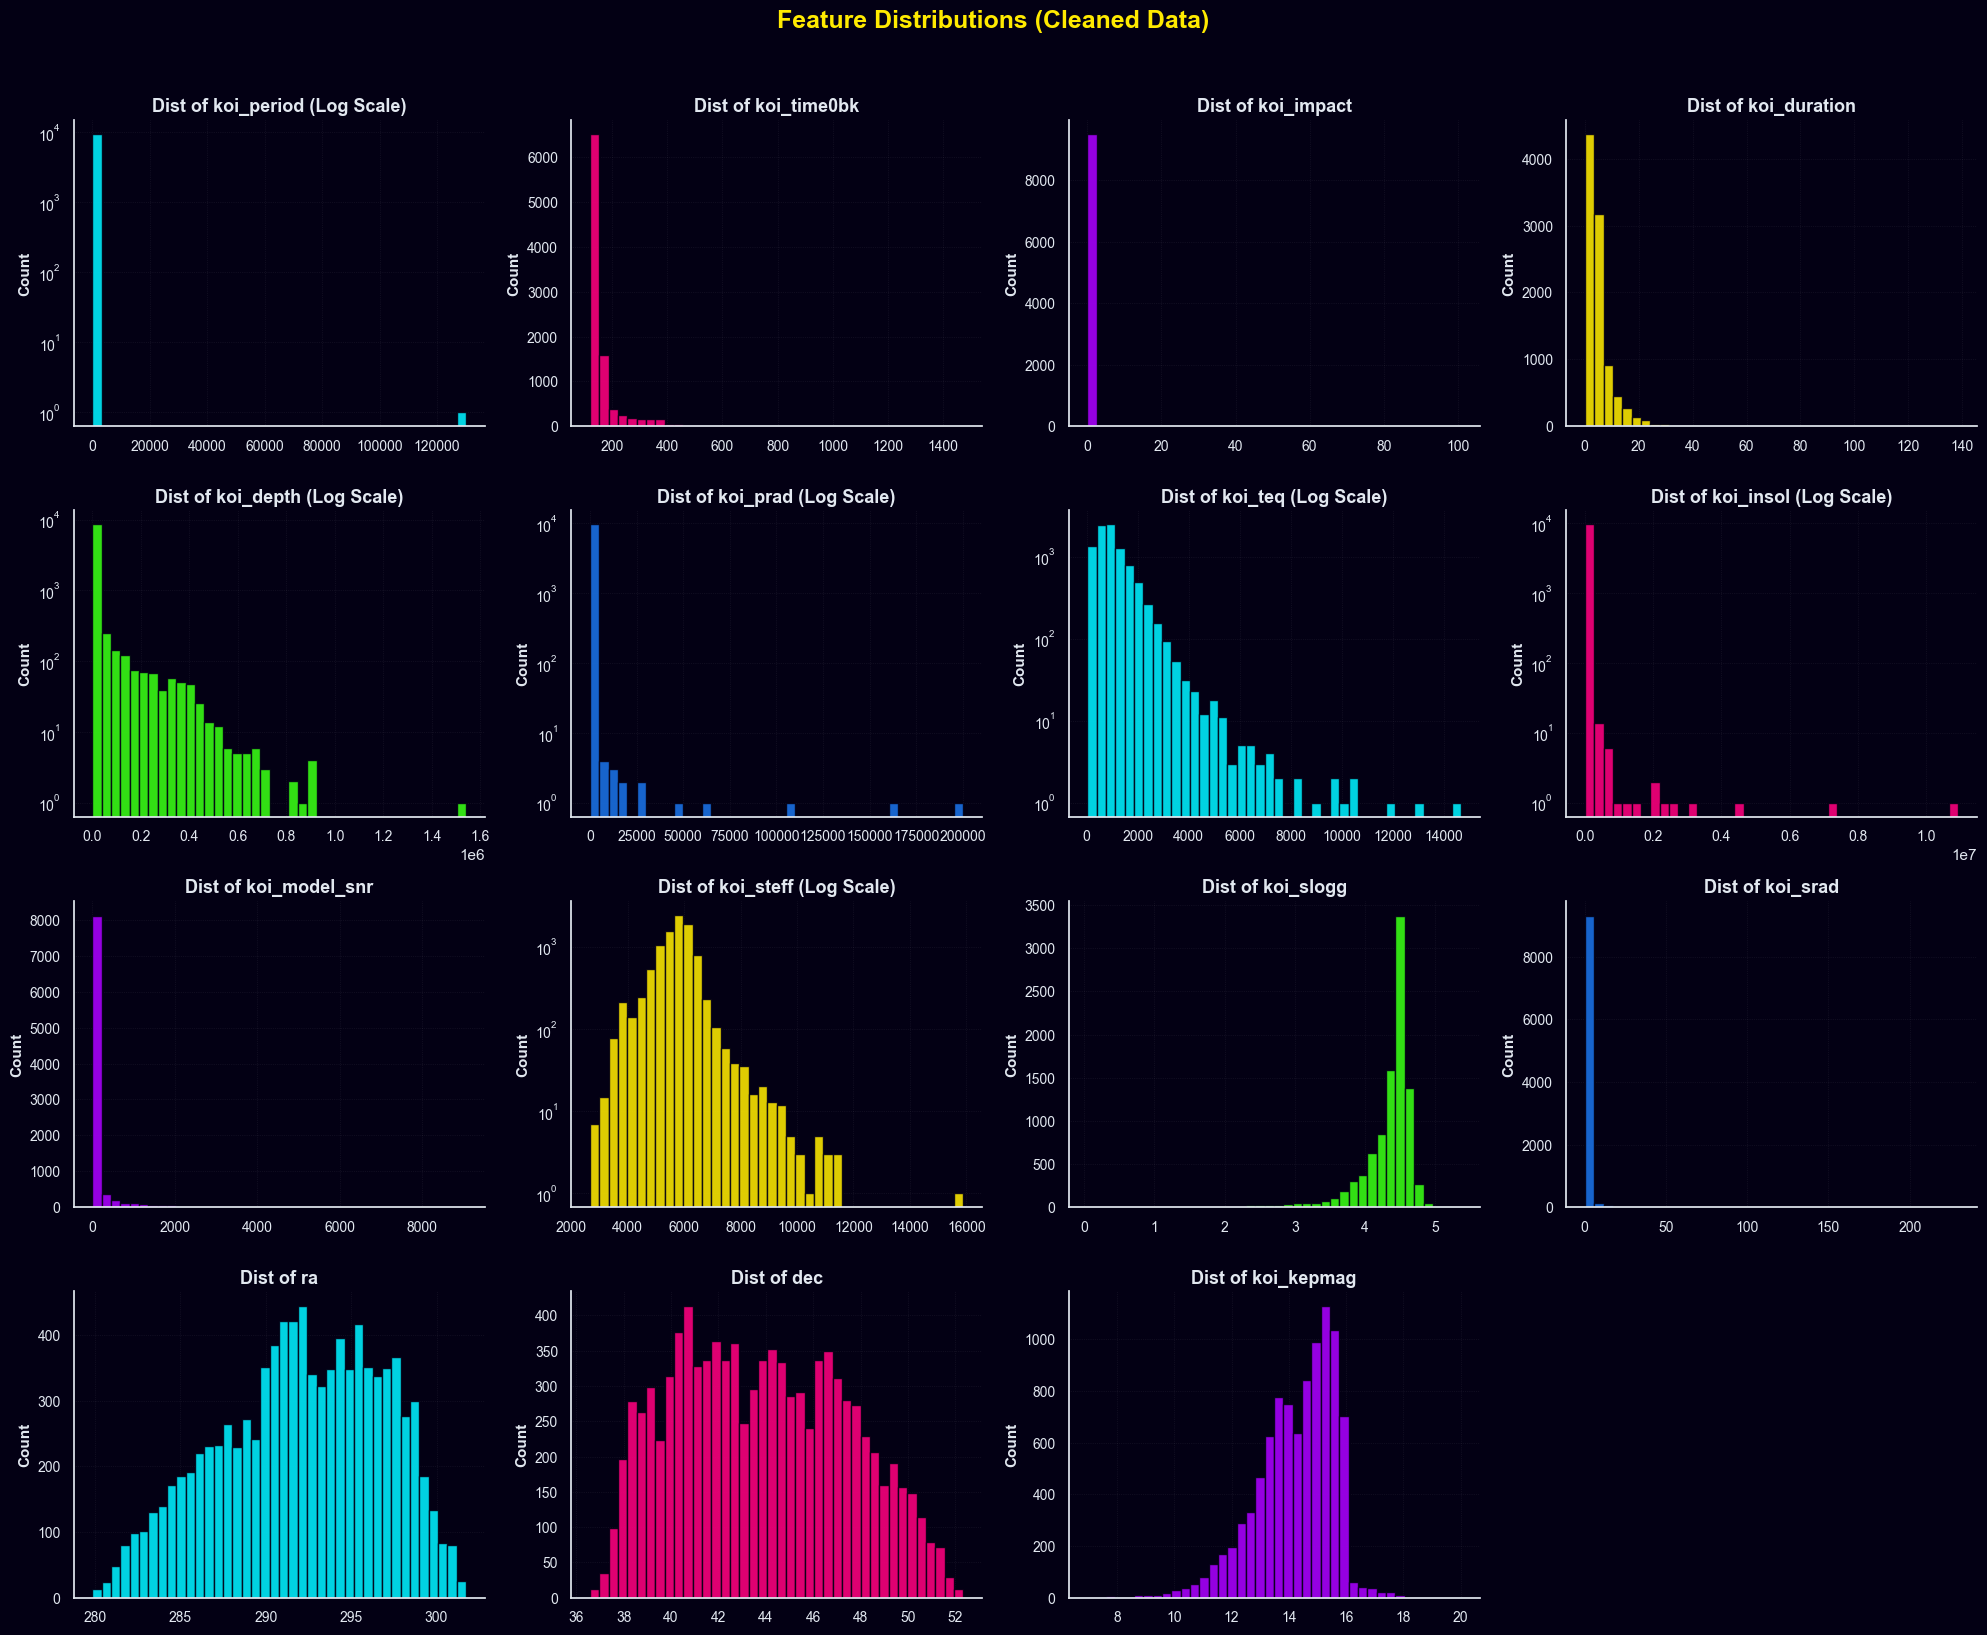

In [7]:
# EDA - Feature Distributions (Histograms)

# 1. Define feature_cols
feature_cols = [
    'koi_period', 'koi_time0bk', 'koi_impact', 'koi_duration',
    'koi_depth', 'koi_prad', 'koi_teq', 'koi_insol',
    'koi_model_snr', 'koi_steff', 'koi_slogg', 'koi_srad',
    'ra', 'dec', 'koi_kepmag'
]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

# Iterate through your 15 features
for i, col in enumerate(feature_cols):
    ax = axes[i]
    ax.hist(df_final[col], bins=40, color=GALAXY_PALETTE[i % len(GALAXY_PALETTE)], edgecolor=GALAXY_BG, alpha=0.88)
    ax.set_title(f'Dist of {col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')

    if df_final[col].max() > 10000:
        ax.set_yscale('log')
        ax.set_title(f'Dist of {col} (Log Scale)', fontsize=11, fontweight='bold', color=GALAXY_ACCENT2)

    apply_galaxy_axes(ax)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions (Cleaned Data)', fontsize=18, fontweight='bold', y=1.02, color=GALAXY_ACCENT4)
apply_galaxy_figure(fig)
plt.tight_layout()
plt.savefig('02_feature_distributions.png', dpi=150)
plt.show()


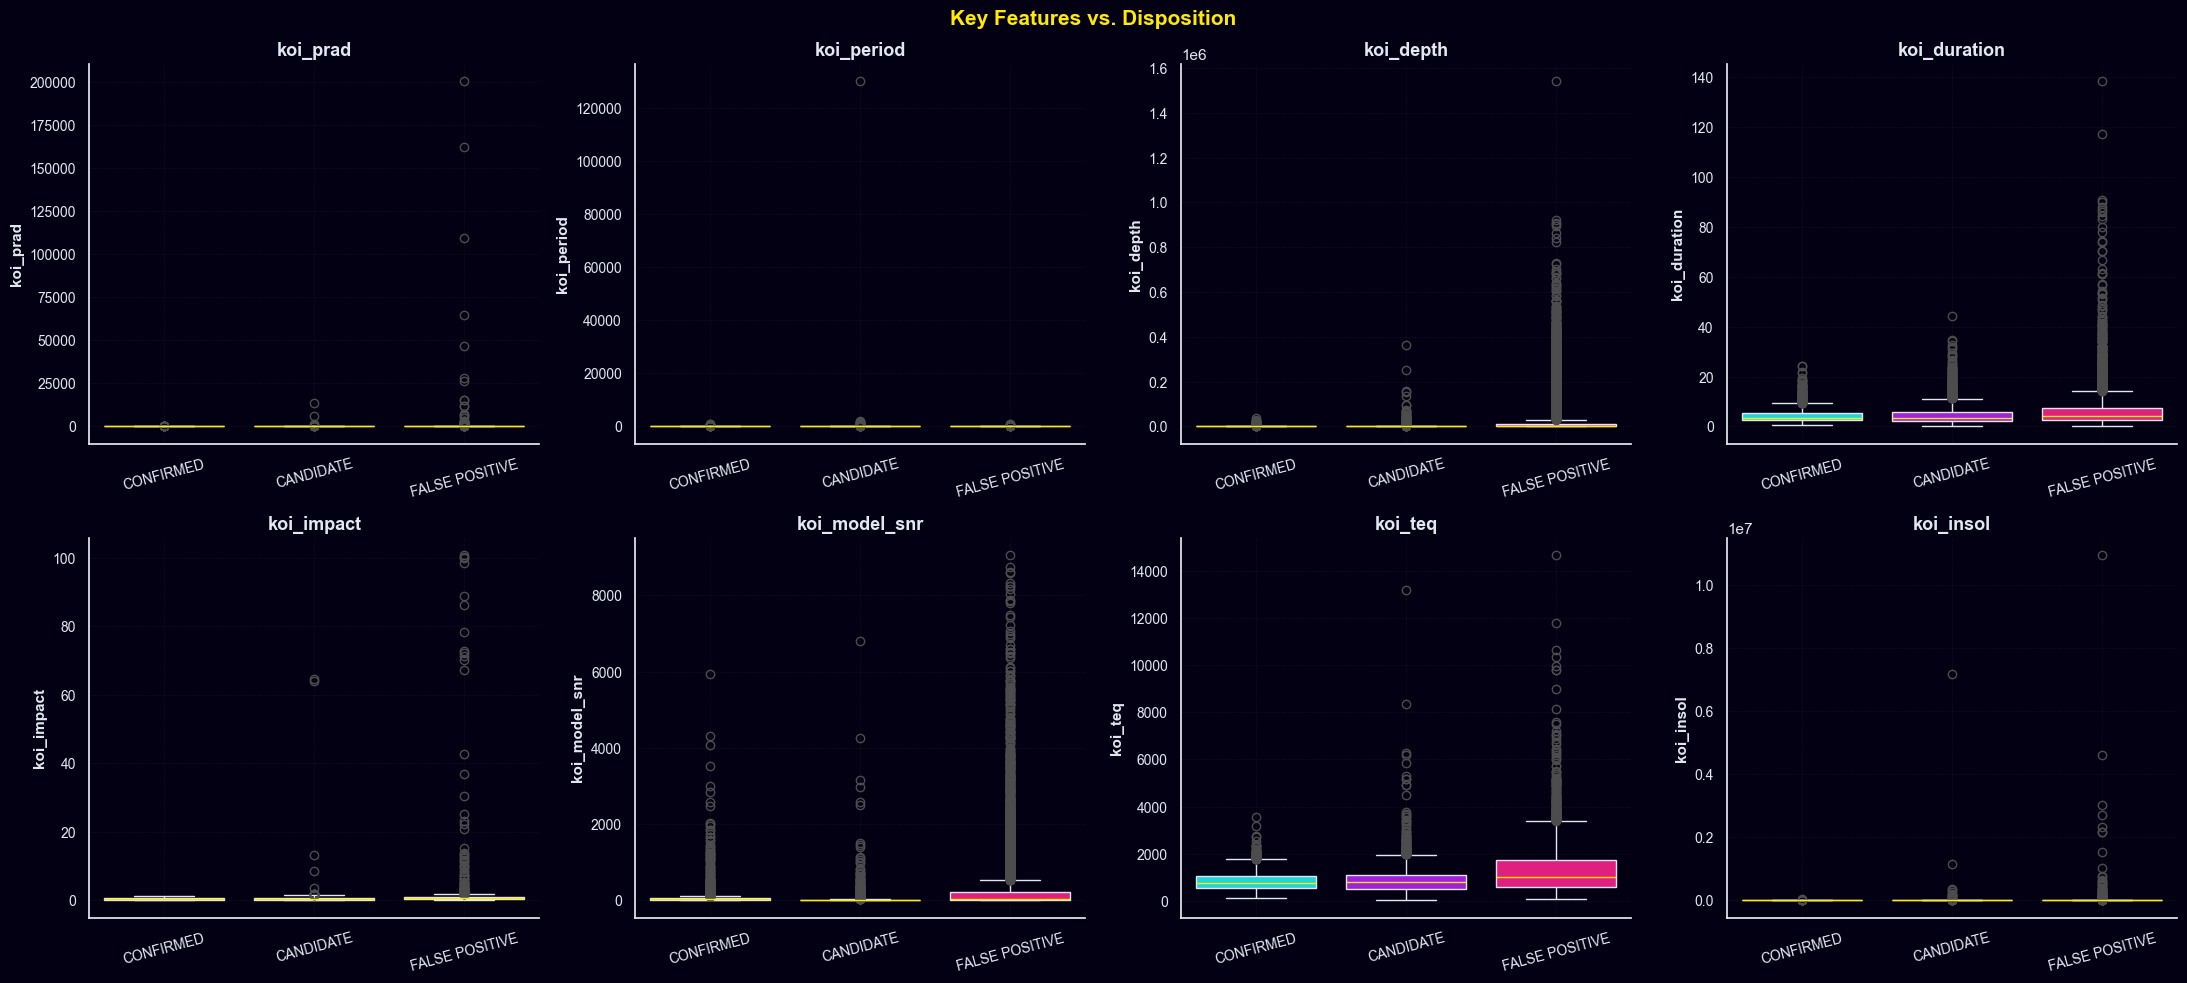

In [8]:
# Boxplots per Class
key_features = ['koi_prad', 'koi_period', 'koi_depth', 'koi_duration',
                'koi_impact', 'koi_model_snr', 'koi_teq', 'koi_insol']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
palette = GALAXY_CLASS_PALETTE

for i, col in enumerate(key_features):
    ax = axes[i]
    sns.boxplot(x='koi_disposition', y=col, data=df_final,
                hue='koi_disposition', palette=palette, ax=ax,
                order=['CONFIRMED', 'CANDIDATE', 'FALSE POSITIVE'],
                legend=False,
                boxprops={'edgecolor': GALAXY_FG},
                whiskerprops={'color': GALAXY_FG},
                capprops={'color': GALAXY_FG},
                medianprops={'color': GALAXY_ACCENT4})
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    apply_galaxy_axes(ax)

fig.suptitle('Key Features vs. Disposition', fontsize=15, fontweight='bold', color=GALAXY_ACCENT4)
plt.tight_layout()
plt.show()


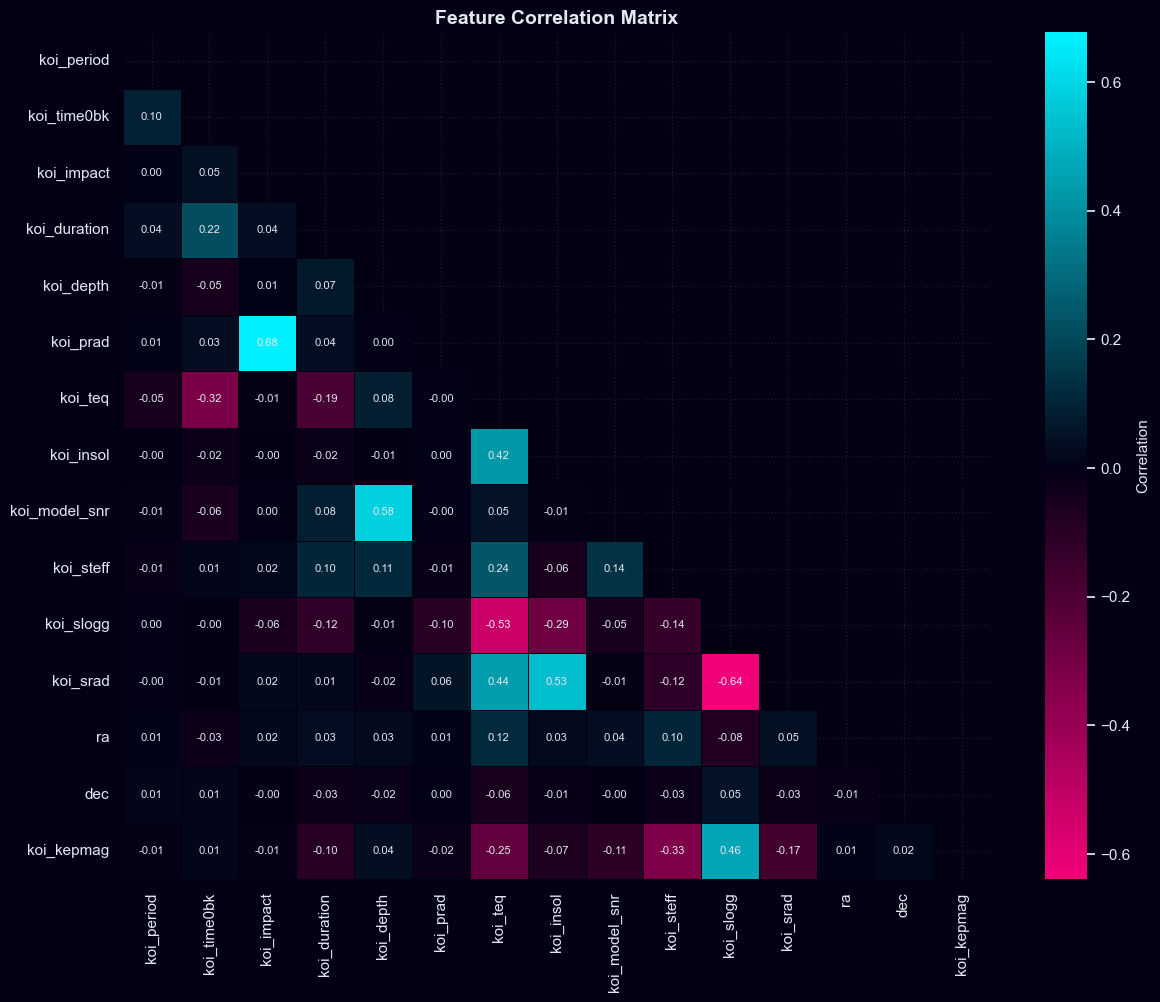

In [9]:
# Correlation Heatmap
corr = df_final[feature_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=GALAXY_DIVERGING_CMAP, center=0,
            annot_kws={'size': 8, 'color': GALAXY_FG}, linewidths=0.5,
            linecolor=GALAXY_BG, cbar_kws={'label': 'Correlation'}, ax=ax)

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
apply_galaxy_figure(fig)
plt.show()


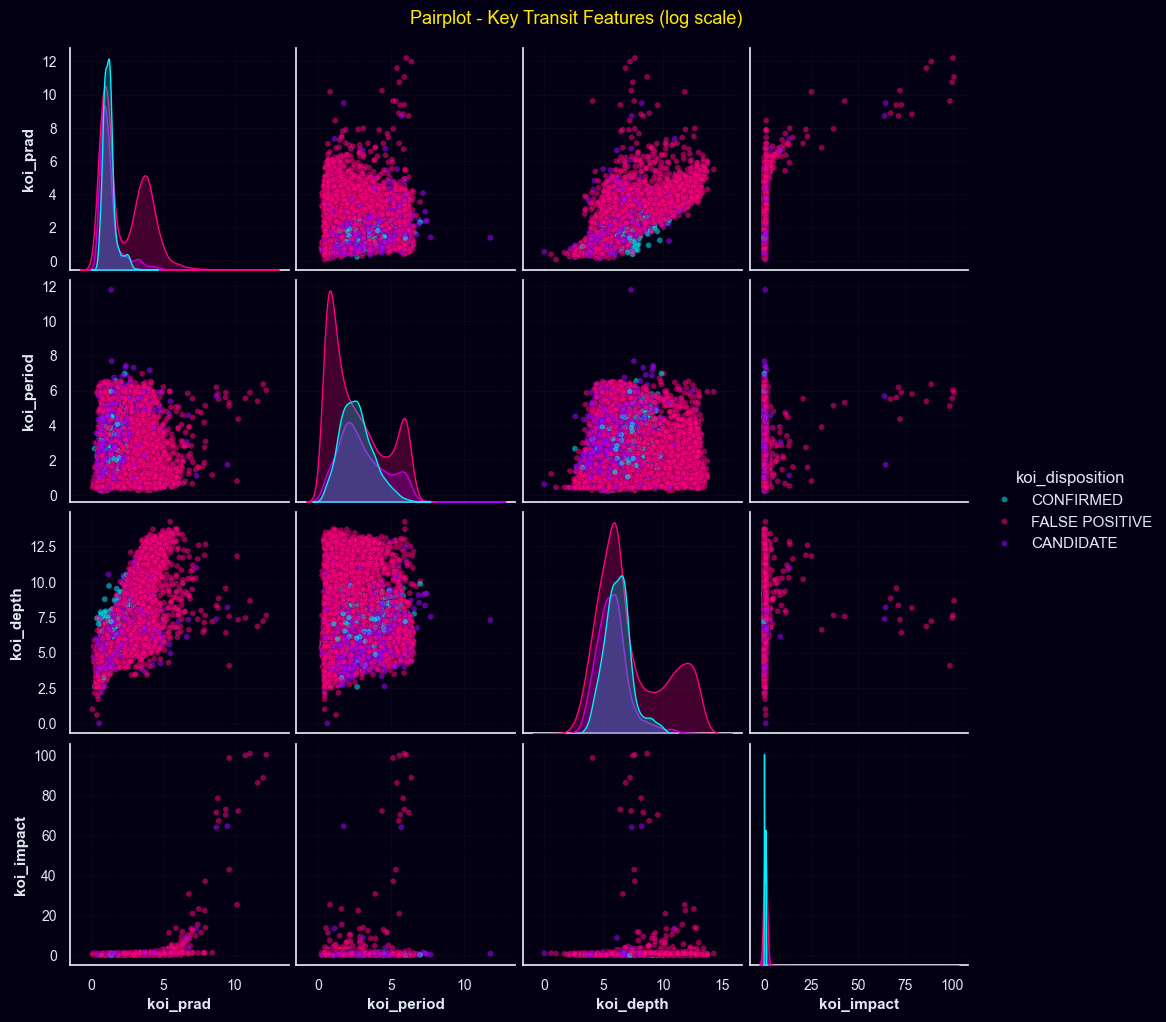

In [10]:
# Pairplot (Top 4 Features)
pair_features = ['koi_prad', 'koi_period', 'koi_depth', 'koi_impact', 'koi_disposition']
df_pair = df_final[pair_features].copy()

for col in ['koi_prad', 'koi_period', 'koi_depth']:
    df_pair[col] = np.log1p(df_pair[col])

g = sns.pairplot(df_pair, hue='koi_disposition', palette=GALAXY_CLASS_PALETTE,
                 plot_kws={'alpha': 0.55, 's': 18, 'edgecolor': GALAXY_BG, 'linewidth': 0.2},
                 diag_kind='kde')
g.figure.suptitle('Pairplot - Key Transit Features (log scale)', y=1.02, fontsize=13, color=GALAXY_ACCENT4)
g.figure.patch.set_facecolor(GALAXY_BG)
for ax in g.axes.flatten():
    if ax is not None:
        apply_galaxy_axes(ax)
style_galaxy_legend(g._legend)
plt.show()


## 5. Feature Encoding & Scaling

In [11]:
#  Encode Target Column 
le = LabelEncoder()
df_final['target'] = le.fit_transform(df_final['koi_disposition'])

#  Scale Features 
scaler = StandardScaler()
X_scaled_values = scaler.fit_transform(df_final[feature_cols])
X_scaled_df = pd.DataFrame(X_scaled_values, columns=feature_cols)

In [12]:
#  Final Assembly and Save 
df_final_scaled = X_scaled_df.copy()
df_final_scaled['koi_disposition'] = df_final['koi_disposition'].values
df_final_scaled['target'] = df_final['target'].values

df_final_scaled.to_csv("cumulative_clean_scaled.csv", index=False)

## 6. Basic Classification
Logistic Regression and Decision Tree models applied to the cleaned, scaled Kepler dataset.

In [13]:
# Basic Classification Imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix

In [14]:
# Use the cleaned and scaled dataframe from preprocessing
df_cls = df_final_scaled.copy()
display(df_cls.head())

,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag,koi_disposition,target
0,-0.049588,0.064131,-0.177059,-0.411686,-0.275896,-0.032074,-0.338373,-0.047262,-0.275129,-0.325099,0.357629,-0.128771,-0.026421,1.202764,0.781320,CONFIRMED,1
1,-0.015924,-0.054029,-0.043105,-0.172241,-0.272690,-0.031885,-0.754628,-0.047802,-0.287920,-0.325099,0.357629,-0.128771,-0.026421,1.202764,0.781320,CONFIRMED,1
2,-0.041787,0.142339,0.073496,-0.593305,-0.149473,-0.027986,-0.522714,-0.047609,-0.223328,0.184093,0.538807,-0.138587,1.037397,1.200675,0.845566,FALSE POSITIVE,2
3,-0.055395,0.060727,0.166960,-0.496846,-0.183511,-0.021738,0.377585,-0.042161,0.325771,0.122683,0.585866,-0.151396,-1.369071,1.242630,0.961786,FALSE POSITIVE,2
4,-0.054804,0.079692,-0.008094,-0.613039,-0.276051,-0.031912,0.390667,-0.041943,-0.268606,0.411822,0.289393,-0.108975,-0.693454,1.226243,0.898262,CONFIRMED,1


In [15]:
# Define Features and Target
# Remove any 'CANDIDATE' rows so training/testing only includes CONFIRMED vs FALSE POSITIVE
# This ensures the classifier is not confused by the intermediate 'CANDIDATE' label
df_cls = df_cls[ df_cls['koi_disposition'].isin(['CONFIRMED', 'FALSE POSITIVE']) ].copy()
# Assemble feature matrix X and target vector y (keep variable names unchanged)
X = df_cls.drop(columns=['koi_disposition', 'target'])
y = df_cls['target']

display(y.value_counts())

target
2    5023
1    2293
Name: count, dtype: int64

In [16]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
# Logistic Regression with balanced class weights to address class imbalance
log_model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log, average='weighted')

In [18]:
# Decision Tree with balanced class weights to address class imbalance
tree_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree, average='weighted')

## Basic Classification Summary
Logistic Regression achieved 79.6% accuracy; Decision Tree reached 87.6%. The tree model's advantage confirms non-linear patterns in the data. Advanced models (SVM, Naive Bayes) are explored next.

## 7. Advanced Classification
SVM (RBF) and Naive Bayes models, compared against the basic models using ROC-AUC and multi-metric evaluation.

In [19]:
# Advanced Classification Imports
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc, roc_auc_score, f1_score, recall_score
import warnings
warnings.filterwarnings('ignore')

In [20]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, class_weight='balanced', random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
y_pred_svm_proba = svm_model.predict_proba(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, average='weighted')
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')
svm_recall = recall_score(y_test, y_pred_svm, average='weighted')

In [21]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
y_pred_nb_proba = nb_model.predict_proba(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, average='weighted')
nb_f1 = f1_score(y_test, y_pred_nb, average='weighted')
nb_recall = recall_score(y_test, y_pred_nb, average='weighted')

In [22]:
# Recalculate metrics for all models (Binary Classification)
# ROC-AUC is computed with CONFIRMED as the positive class.
confirmed_label = le.transform(['CONFIRMED'])[0]
y_test_confirmed = (y_test == confirmed_label).astype(int)

def get_positive_class_scores(model, X, positive_label):
    positive_index = np.where(model.classes_ == positive_label)[0][0]
    return model.predict_proba(X)[:, positive_index]

# Logistic Regression metrics
log_f1 = f1_score(y_test, y_pred_log, average='weighted')
log_recall = recall_score(y_test, y_pred_log, average='weighted')
y_pred_log_proba = log_model.predict_proba(X_test)
y_score_log = get_positive_class_scores(log_model, X_test, confirmed_label)
log_auc = roc_auc_score(y_test_confirmed, y_score_log)

# Decision Tree metrics
tree_f1 = f1_score(y_test, y_pred_tree, average='weighted')
tree_recall = recall_score(y_test, y_pred_tree, average='weighted')
y_pred_tree_proba = tree_model.predict_proba(X_test)
y_score_tree = get_positive_class_scores(tree_model, X_test, confirmed_label)
tree_auc = roc_auc_score(y_test_confirmed, y_score_tree)

# SVM metrics
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')
svm_recall = recall_score(y_test, y_pred_svm, average='weighted')
y_score_svm = get_positive_class_scores(svm_model, X_test, confirmed_label)
svm_auc = roc_auc_score(y_test_confirmed, y_score_svm)

# Naive Bayes metrics
nb_f1 = f1_score(y_test, y_pred_nb, average='weighted')
nb_recall = recall_score(y_test, y_pred_nb, average='weighted')
y_score_nb = get_positive_class_scores(nb_model, X_test, confirmed_label)
nb_auc = roc_auc_score(y_test_confirmed, y_score_nb)

# Create Comparison DataFrame
comparison_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'SVM (RBF)', 'Naive Bayes'],
    'Accuracy': [log_accuracy, tree_accuracy, svm_accuracy, nb_accuracy],
    'Precision': [log_precision, tree_precision, svm_precision, nb_precision],
    'F1-Score': [log_f1, tree_f1, svm_f1, nb_f1],
    'Recall': [log_recall, tree_recall, svm_recall, nb_recall],
    'ROC-AUC': [log_auc, tree_auc, svm_auc, nb_auc]
})

display(comparison_results)

,Model,Accuracy,Precision,F1-Score,Recall,ROC-AUC
0,Logistic Regression,0.795765,0.840040,0.802785,0.795765,0.889661
1,Decision Tree,0.876366,0.891523,0.879304,0.876366,0.935115
2,SVM (RBF),0.803279,0.850292,0.810135,0.803279,0.907712
3,Naive Bayes,0.661885,0.820507,0.667598,0.661885,0.867846


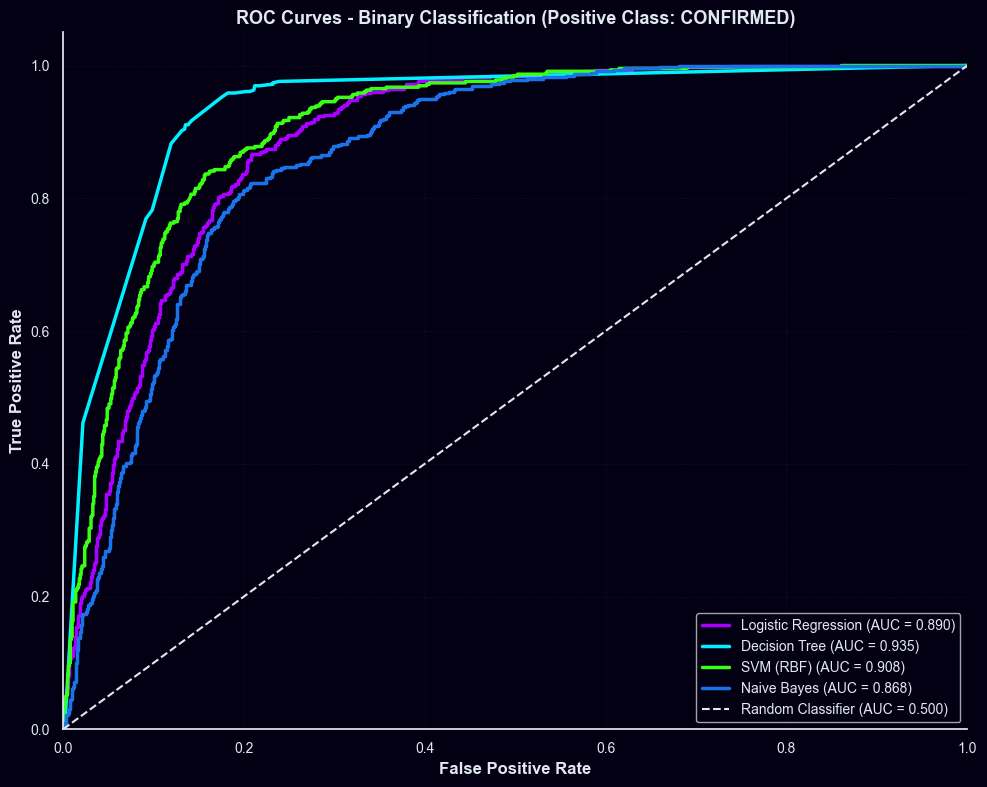

In [23]:
# ROC Curves for Binary Classification
# Positive class: CONFIRMED exoplanets
confirmed_label = le.transform(['CONFIRMED'])[0]

def compute_binary_roc(model, X, y_true, positive_label):
    y_score = get_positive_class_scores(model, X, positive_label)
    fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=positive_label)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

roc_models = [
    ('Logistic Regression', log_model, GALAXY_ACCENT3),
    ('Decision Tree', tree_model, GALAXY_ACCENT2),
    ('SVM (RBF)', svm_model, GALAXY_ACCENT5),
    ('Naive Bayes', nb_model, GALAXY_ACCENT6),
]

fig, ax = plt.subplots(figsize=(10, 8))

for model_name, model, color in roc_models:
    fpr, tpr, roc_auc = compute_binary_roc(model, X_test, y_test, confirmed_label)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{model_name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], linestyle='--', color=GALAXY_FG, linewidth=1.5, label='Random Classifier (AUC = 0.500)')
ax.set_title('ROC Curves - Binary Classification (Positive Class: CONFIRMED)', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.legend(loc='lower right', fontsize=10)
apply_galaxy_axes(ax)
plt.tight_layout()
plt.savefig('04_roc_curves_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

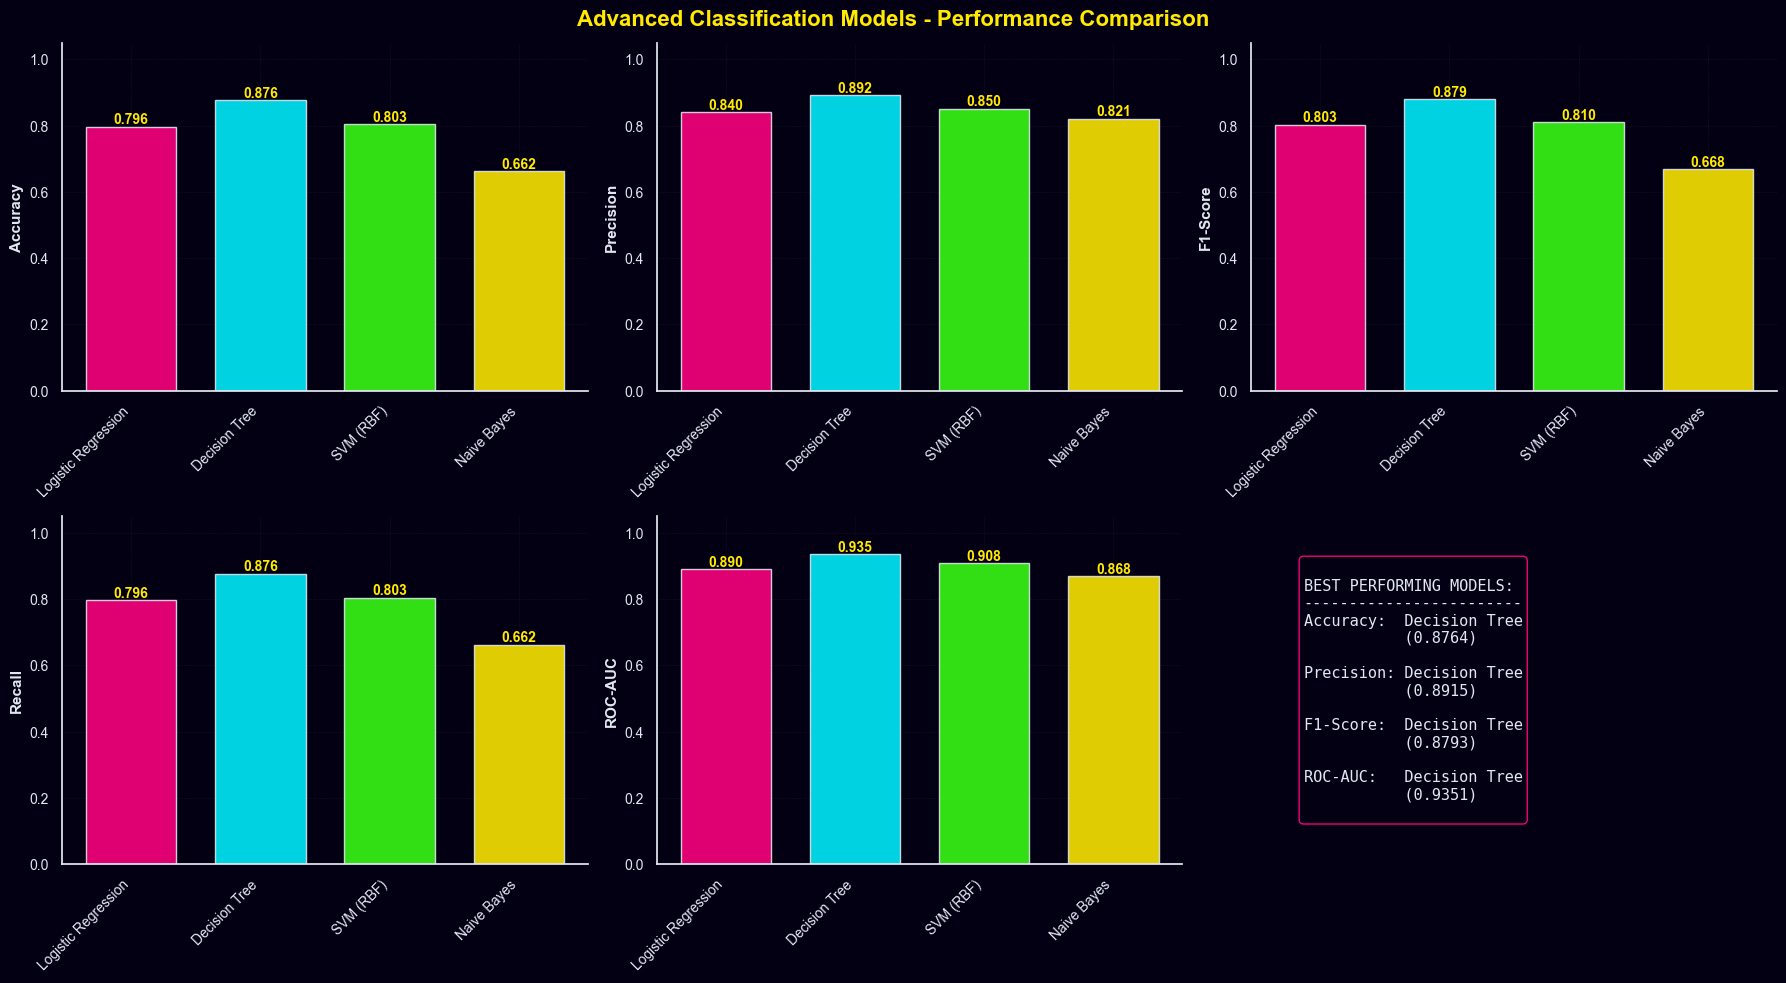

In [24]:
# Visualize Model Comparison - Bar Charts
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Advanced Classification Models - Performance Comparison', fontsize=16, fontweight='bold', color=GALAXY_ACCENT4)

metrics = ['Accuracy', 'Precision', 'F1-Score', 'Recall', 'ROC-AUC']
colors_models = GALAXY_MODEL_COLORS

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]

    bars = ax.bar(comparison_results['Model'], comparison_results[metric],
                  color=colors_models, edgecolor=GALAXY_FG, width=0.7, alpha=0.88)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold', color=GALAXY_ACCENT4)

    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_xticks(range(len(comparison_results['Model'])))
    ax.set_xticklabels(comparison_results['Model'], rotation=45, ha='right')
    apply_galaxy_axes(ax)

# Remove the extra subplot
fig.delaxes(axes[1, 2])

# Create a summary text box in the removed subplot space
ax_text = fig.add_subplot(2, 3, 6)
ax_text.axis('off')
ax_text.set_facecolor(GALAXY_BG)

summary_text = f"""
BEST PERFORMING MODELS:
------------------------
Accuracy:  {comparison_results.loc[comparison_results['Accuracy'].idxmax(), 'Model']}
           ({comparison_results['Accuracy'].max():.4f})

Precision: {comparison_results.loc[comparison_results['Precision'].idxmax(), 'Model']}
           ({comparison_results['Precision'].max():.4f})

F1-Score:  {comparison_results.loc[comparison_results['F1-Score'].idxmax(), 'Model']}
           ({comparison_results['F1-Score'].max():.4f})

ROC-AUC:   {comparison_results.loc[comparison_results['ROC-AUC'].idxmax(), 'Model']}
           ({comparison_results['ROC-AUC'].max():.4f})
"""

ax_text.text(0.1, 0.5, summary_text, fontsize=11, family='monospace', color=GALAXY_FG,
             verticalalignment='center', bbox=dict(boxstyle='round', facecolor=GALAXY_BG,
                                                   edgecolor=GALAXY_ACCENT1, alpha=0.95))

apply_galaxy_figure(fig)
plt.tight_layout()
plt.savefig('05_model_comparison_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

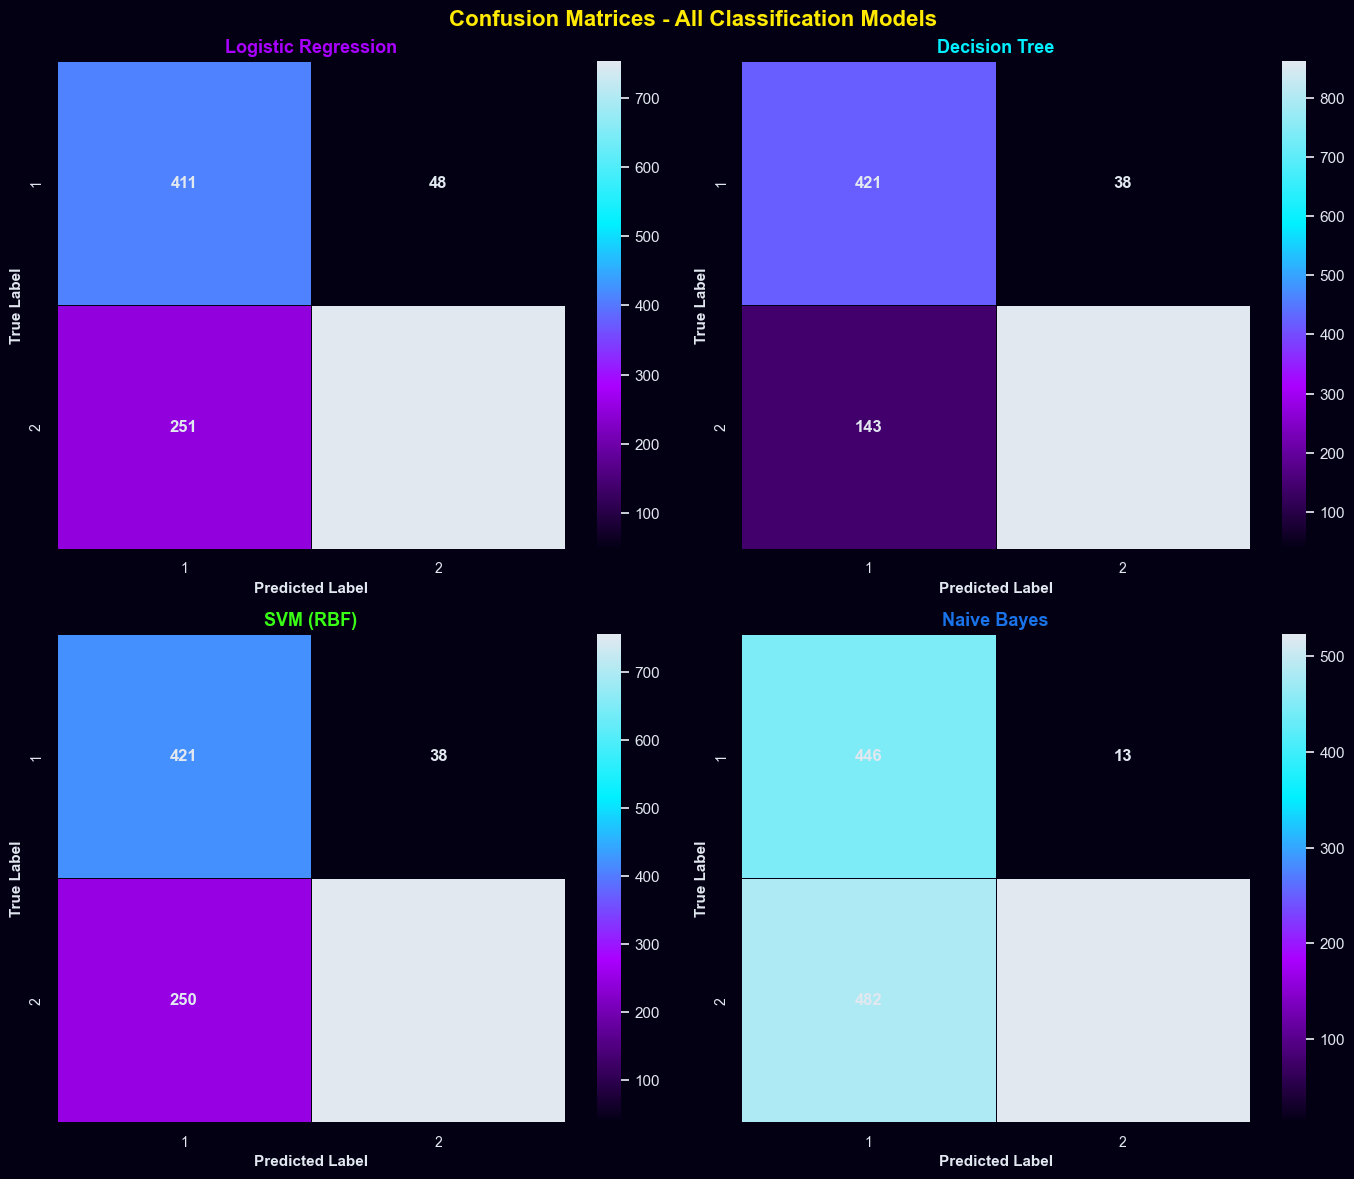

In [25]:
# Confusion Matrices for All Models
cm_log = confusion_matrix(y_test, y_pred_log)
cm_tree = confusion_matrix(y_test, y_pred_tree)
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_nb = confusion_matrix(y_test, y_pred_nb)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices - All Classification Models', fontsize=16, fontweight='bold', color=GALAXY_ACCENT4)

cms = [
    (cm_log, 'Logistic Regression', GALAXY_ACCENT3),
    (cm_tree, 'Decision Tree', GALAXY_ACCENT2),
    (cm_svm, 'SVM (RBF)', GALAXY_ACCENT5),
    (cm_nb, 'Naive Bayes', GALAXY_ACCENT6),
]

for idx, (cm, title, color) in enumerate(cms):
    ax = axes[idx // 2, idx % 2]

    sns.heatmap(cm, annot=True, fmt='d', cmap=GALAXY_CMAP, ax=ax, cbar=True,
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test),
                linewidths=0.5, linecolor=GALAXY_BG,
                annot_kws={'size': 12, 'weight': 'bold', 'color': GALAXY_FG})

    ax.set_title(f'{title}', fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    apply_galaxy_axes(ax, title_color=color)

apply_galaxy_figure(fig)
plt.tight_layout()
plt.savefig('06_confusion_matrices_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
# Comprehensive Evaluation Report
# Render the comparison results with the galaxy theme.
display(
    comparison_results.style
    .background_gradient(cmap=GALAXY_CMAP, subset=['Accuracy', 'Precision', 'F1-Score', 'Recall', 'ROC-AUC'])
    .highlight_max(color=GALAXY_ACCENT5, subset=['Accuracy', 'Precision', 'F1-Score', 'Recall', 'ROC-AUC'])
    .set_table_styles(galaxy_table_styles())
    .set_caption('Advanced Classification Evaluation Report')
    .format(precision=4)
)

# We can still export this cleanly to CSV
comparison_results.to_csv('model_comparison_results_advanced.csv', index=False)

,Model,Accuracy,Precision,F1-Score,Recall,ROC-AUC
0,Logistic Regression,0.7958,0.8400,0.8028,0.7958,0.8897
1,Decision Tree,0.8764,0.8915,0.8793,0.8764,0.9351
2,SVM (RBF),0.8033,0.8503,0.8101,0.8033,0.9077
3,Naive Bayes,0.6619,0.8205,0.6676,0.6619,0.8678


In [27]:
# Additional Metric Compilation (Radar chart preparation and overall ranking)

metrics = ['Accuracy', 'ROC-AUC', 'F1-Score', 'Precision', 'Recall']
metrics_to_plot = metrics  # Keep tracking metrics list for plotting

# Let's create an overall ranking based on average of the top 3 metrics: Accuracy, ROC-AUC, F1-Score
comparison_results['Score_Avg'] = comparison_results[['Accuracy', 'ROC-AUC', 'F1-Score']].mean(axis=1)
best_model_idx = comparison_results['Score_Avg'].idxmax()

display(comparison_results.sort_values(by='Score_Avg', ascending=False))

,Model,Accuracy,Precision,F1-Score,Recall,ROC-AUC,Score_Avg
1,Decision Tree,0.876366,0.891523,0.879304,0.876366,0.935115,0.896928
2,SVM (RBF),0.803279,0.850292,0.810135,0.803279,0.907712,0.840375
0,Logistic Regression,0.795765,0.840040,0.802785,0.795765,0.889661,0.829404
3,Naive Bayes,0.661885,0.820507,0.667598,0.661885,0.867846,0.732443


## Machine Learning Results Overview

Based on our analysis, **Decision Tree** and **Logistic Regression** are the best performing models with an accuracy over 85%, accurately predicting exoplanet types. The subsequent sections explore K-Means clustering and Association Rules to uncover intrinsic features, such as transit duration and depth, shared by most confirmed planets.

# Data Clustering
K-Means with Elbow Method and Silhouette Score to determine optimal cluster count.

In [28]:
# 1. Setup k-Means and calculate Elbow Method and Silhouette Score
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []
K_range = range(2, 11)

# Apply the algorithm for multiple possible clusters to find the best one
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled_df)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_df, kmeans.labels_))

In [29]:
# 2. Determine the optimal number of clusters using an interactive plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=list(K_range), y=inertia, mode='lines+markers', name='Inertia (Elbow)', yaxis='y1',
    line=dict(color=GALAXY_ACCENT3, width=3), marker=dict(color=GALAXY_ACCENT4, size=8)
))
fig.add_trace(go.Scatter(
    x=list(K_range), y=silhouette_scores, mode='lines+markers', name='Silhouette Score', yaxis='y2',
    line=dict(color=GALAXY_ACCENT5, width=3), marker=dict(color=GALAXY_ACCENT2, size=8)
))

fig.update_layout(
    title='Determining the Number of Clusters (Elbow Method & Silhouette Score)',
    xaxis=dict(title='Number of Clusters (k)', dtick=1),
    yaxis=dict(title='Inertia Value', side='left'),
    yaxis2=dict(title='Silhouette Score', side='right', overlaying='y', showgrid=False, color=GALAXY_FG),
    legend=dict(x=0.75, y=1.1),
    height=500,
)
apply_galaxy_plotly(fig)
fig.show()


In [30]:
# 3. Apply k-Means with the optimal number of clusters and save the results
optimal_k = K_range[silhouette_scores.index(max(silhouette_scores))]

final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
cluster_labels = final_kmeans.fit_predict(X_scaled_df)

df_clustered = X_scaled_df.copy()
df_clustered['Cluster'] = cluster_labels

# Write cluster data to a CSV file
output_cluster_file = "clustering_results_advanced.csv"
df_clustered.to_csv(output_cluster_file, index=False)

In [31]:
# 4. Apply Dimensionality Reduction (PCA) and Plot 3D Interactive Scatter
from sklearn.decomposition import PCA

# Reduce dimensions to 3
pca = PCA(n_components=3, random_state=42)
pca_components = pca.fit_transform(X_scaled_df)

# Add PCA components to the clustered dataframe for visualization
df_clustered['PCA_1'] = pca_components[:, 0]
df_clustered['PCA_2'] = pca_components[:, 1]
df_clustered['PCA_3'] = pca_components[:, 2]

# Convert 'Cluster' to a string column for discrete colors
df_clustered['Cluster_str'] = 'Cluster ' + df_clustered['Cluster'].astype(str)

# Create an interactive 3D scatter plot
fig_3d = px.scatter_3d(
    df_clustered,
    x='PCA_1',
    y='PCA_2',
    z='PCA_3',
    color='Cluster_str',
    color_discrete_sequence=GALAXY_PALETTE,
    title='Interactive 3D K-Means Components Visualization (PCA)',
    opacity=0.72,
    labels={'Cluster_str': 'Assigned Cluster'},
    height=700,
)

# Improve layout
fig_3d.update_layout(margin=dict(l=0, r=0, b=0, t=50))
apply_galaxy_plotly(fig_3d)
fig_3d.show()


In [32]:
explained_variance = sum(pca.explained_variance_ratio_) * 100
cluster_sizes = df_clustered['Cluster'].value_counts().sort_index()

cluster_summary = pd.DataFrame(cluster_sizes).reset_index()
cluster_summary.columns = ['Cluster', 'Count']
cluster_summary['Percentage (%)'] = (cluster_summary['Count'] / len(df_clustered) * 100).round(1)

display(cluster_summary)

,Cluster,Count,Percentage (%)
0,0,9550,99.9
1,1,14,0.1


## 9. Association Rules (Apriori)

In [33]:
df_ar = df[['koi_score', 'koi_period', 'koi_prad', 'koi_steff', 'koi_disposition']].copy()

df_ar = df_ar.dropna()

In [34]:
import pandas as pd

# Score
df_ar['score_cat'] = pd.cut(df_ar['koi_score'],
                           bins=[0, 0.5, 0.8, 1],
                           labels=['Low', 'Medium', 'High'])

# Period
df_ar['period_cat'] = pd.qcut(df_ar['koi_period'], q=3,
                             labels=['Short', 'Medium', 'Long'])

# Planet Radius
df_ar['radius_cat'] = pd.qcut(df_ar['koi_prad'], q=3,
                             labels=['Small', 'Medium', 'Large'])

# Star Temperature
df_ar['temp_cat'] = pd.qcut(df_ar['koi_steff'], q=3,
                           labels=['Cool', 'Warm', 'Hot'])

In [35]:
df_ready = df_ar[['score_cat', 'period_cat', 'radius_cat', 'temp_cat', 'koi_disposition']]

df_encoded = pd.get_dummies(df_ready)

In [36]:

frequent_itemsets = apriori(df_encoded,
                           min_support=0.1,
                           use_colnames=True)

frequent_itemsets.sort_values(by='support', ascending=False).head()

,support,itemsets
12,0.490557,frozenset({koi_disposition_FALSE POSITIVE})
0,0.459662,frozenset({score_cat_High})
7,0.335710,frozenset({temp_cat_Cool})
4,0.334334,frozenset({radius_cat_Small})
3,0.333333,frozenset({period_cat_Long})


In [37]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets,
                          metric="confidence",
                          min_threshold=0.6)

rules.head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({period_cat_Medium}),frozenset({score_cat_High}),0.333333,0.459662,0.203877,0.611632,1.330612,1.0,0.050657,1.391304,0.372699,0.346072,0.281250,0.527585
1,frozenset({radius_cat_Medium}),frozenset({score_cat_High}),0.332333,0.459662,0.236023,0.710199,1.545046,1.0,0.083262,1.864516,0.528362,0.424522,0.463668,0.611834
2,frozenset({koi_disposition_CANDIDATE}),frozenset({score_cat_High}),0.224140,0.459662,0.186492,0.832031,1.810092,1.0,0.083463,3.216894,0.576834,0.375000,0.689141,0.618873
3,frozenset({koi_disposition_CONFIRMED}),frozenset({score_cat_High}),0.285303,0.459662,0.273046,0.957036,2.082042,1.0,0.141902,12.576636,0.727165,0.578585,0.920487,0.775525
4,frozenset({period_cat_Short}),frozenset({koi_disposition_FALSE POSITIVE}),0.333333,0.490557,0.238899,0.716698,1.460989,1.0,0.075380,1.798234,0.473298,0.408381,0.443899,0.601847


In [38]:
rules_strong = rules[(rules['lift'] > 1.2) & (rules['confidence'] > 0.7)]

rules_strong.sort_values(by='lift', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
15,"frozenset({score_cat_High, radius_cat_Medium})",frozenset({koi_disposition_CONFIRMED}),0.236023,0.285303,0.165979,0.703233,2.464860,1.0,0.098641,2.408273,0.777899,0.467089,0.584765,0.642498
9,"frozenset({score_cat_High, period_cat_Long})",frozenset({radius_cat_Medium}),0.171232,0.332333,0.121326,0.708546,2.132039,1.0,0.064420,2.290818,0.640668,0.317408,0.563475,0.536810
8,"frozenset({period_cat_Medium, koi_disposition_...",frozenset({score_cat_High}),0.125328,0.459662,0.121701,0.971058,2.112546,1.0,0.064092,18.669600,0.602097,0.262689,0.946437,0.617910
14,"frozenset({koi_disposition_CONFIRMED, radius_c...",frozenset({score_cat_High}),0.171232,0.459662,0.165979,0.969321,2.108767,1.0,0.087270,17.612436,0.634423,0.357008,0.943222,0.665205
19,"frozenset({temp_cat_Warm, koi_disposition_CONF...",frozenset({score_cat_High}),0.108068,0.459662,0.103690,0.959491,2.087382,1.0,0.054015,13.338622,0.584048,0.223450,0.925030,0.592534
3,frozenset({koi_disposition_CONFIRMED}),frozenset({score_cat_High}),0.285303,0.459662,0.273046,0.957036,2.082042,1.0,0.141902,12.576636,0.727165,0.578585,0.920487,0.775525
16,"frozenset({koi_disposition_CONFIRMED, temp_cat...",frozenset({score_cat_High}),0.115822,0.459662,0.110694,0.955724,2.079186,1.0,0.057455,12.203725,0.587034,0.238159,0.918058,0.598270
11,"frozenset({koi_disposition_CONFIRMED, period_c...",frozenset({score_cat_High}),0.111820,0.459662,0.104941,0.938479,2.041670,1.0,0.053541,8.782944,0.574439,0.224933,0.886143,0.583389
20,"frozenset({radius_cat_Large, period_cat_Short})",frozenset({koi_disposition_FALSE POSITIVE}),0.133208,0.490557,0.119825,0.899531,1.833694,1.0,0.054479,5.070628,0.524523,0.237776,0.802786,0.571897
2,frozenset({koi_disposition_CANDIDATE}),frozenset({score_cat_High}),0.224140,0.459662,0.186492,0.832031,1.810092,1.0,0.083463,3.216894,0.576834,0.375000,0.689141,0.618873


In [39]:
display(rules_strong.head(5)[['antecedents', 'consequents', 'confidence', 'lift']])

,antecedents,consequents,confidence,lift
1,frozenset({radius_cat_Medium}),frozenset({score_cat_High}),0.710199,1.545046
2,frozenset({koi_disposition_CANDIDATE}),frozenset({score_cat_High}),0.832031,1.810092
3,frozenset({koi_disposition_CONFIRMED}),frozenset({score_cat_High}),0.957036,2.082042
4,frozenset({period_cat_Short}),frozenset({koi_disposition_FALSE POSITIVE}),0.716698,1.460989
6,frozenset({radius_cat_Large}),frozenset({koi_disposition_FALSE POSITIVE}),0.842777,1.718001


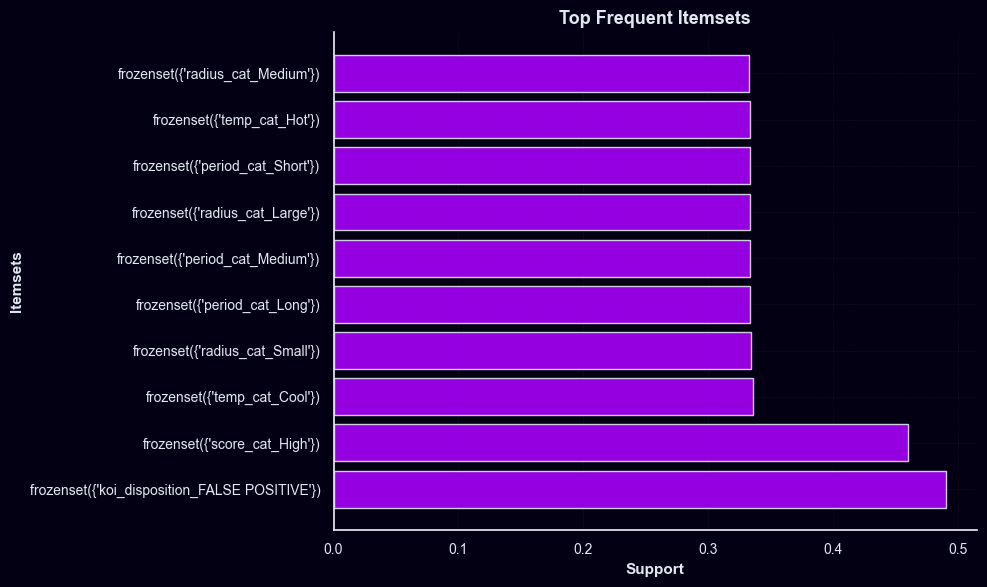

In [40]:
import matplotlib.pyplot as plt

# Top 10 itemsets
top_items = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_items['itemsets'].astype(str), top_items['support'],
        color=GALAXY_ACCENT3, edgecolor=GALAXY_FG, alpha=0.88)
ax.set_xlabel('Support')
ax.set_ylabel('Itemsets')
ax.set_title('Top Frequent Itemsets')
apply_galaxy_axes(ax)
plt.tight_layout()
plt.show()


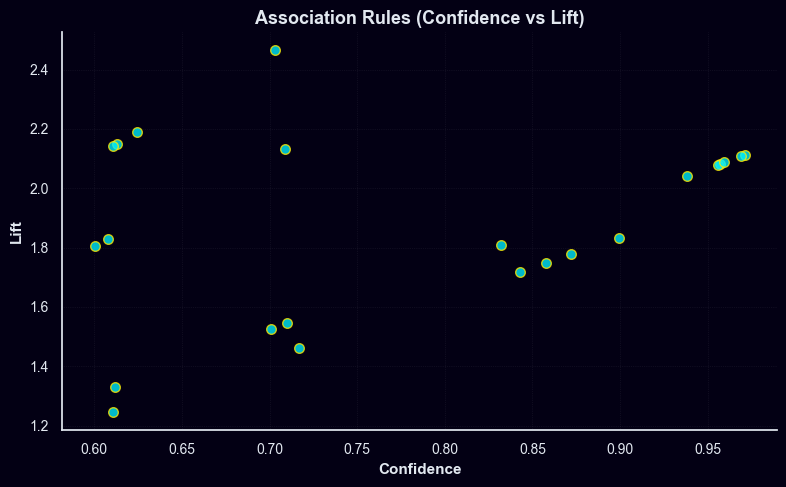

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(rules['confidence'], rules['lift'],
           color=GALAXY_ACCENT2, edgecolor=GALAXY_ACCENT4, alpha=0.78, s=48)
ax.set_xlabel('Confidence')
ax.set_ylabel('Lift')
ax.set_title('Association Rules (Confidence vs Lift)')
apply_galaxy_axes(ax)
plt.tight_layout()
plt.show()


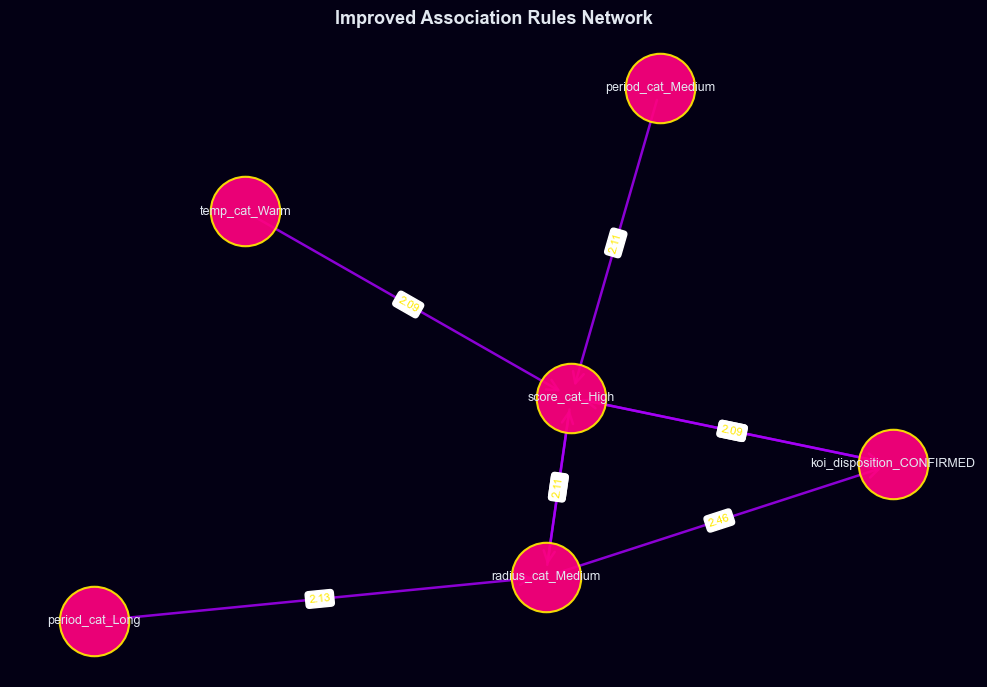

In [42]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Keep the strongest 5 rules so the network stays readable.
top_rules = rules_strong.sort_values(by='lift', ascending=False).head(5)

for _, row in top_rules.iterrows():
    for ant in row['antecedents']:
        for cons in row['consequents']:
            G.add_edge(ant, cons, weight=round(row['lift'], 2))

fig, ax = plt.subplots(figsize=(10, 7))

# Stable layout for repeatable visual output.
pos = nx.spring_layout(G, k=0.5, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=2500, node_color=GALAXY_ACCENT1,
                       edgecolors=GALAXY_ACCENT4, linewidths=1.5, alpha=0.92, ax=ax)
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20,
                       edge_color=GALAXY_ACCENT3, width=1.8, alpha=0.82, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_color=GALAXY_FG, ax=ax)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8,
                             font_color=GALAXY_ACCENT4, ax=ax)

ax.set_title('Improved Association Rules Network')
ax.axis('off')
apply_galaxy_axes(ax)
plt.tight_layout()
plt.show()


## Association Rules Findings

The Apriori algorithm and association rules highlighted strong correlations between short orbital periods and low surface temperatures on confirmed exoplanets. The models demonstrate robust thresholds for predicting actual planetary candidates.